<a href="https://colab.research.google.com/github/helonayala/sysid/blob/main/narmax_example_drone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NARX model

NARX model for the 1/4 drone dataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Install/import the sysid course library (works locally and on Google Colab) ---
try:
    from sysid import NARX, readData
except ImportError:
    !pip install -q git+https://github.com/helonayala/sysid.git
    from sysid import NARX, readData


## Load and preprocess the datasets

Closed-loop 1/4 drone acquisitions. Each signal is sliced to a fixed useful time window (20–80 s) and decimated by a common factor, then stored in a `data` dictionary.

In [2]:
DECIMATION = 5
T_START, T_END = 20.0, 80.0   # hard-coded useful window [s]

def load_processed(name, t0=T_START, t1=T_END, decimation=DECIMATION):
    """Load a 1/4 drone dataset, keep t in [t0, t1] s and decimate. Returns u, y, t, ref."""
    y, u, t, ref = readData('quarter_drone', name, return_ref=True)
    idx = np.where((t >= t0) & (t <= t1))[0]
    sl = slice(idx[0], idx[-1] + 1, decimation)
    return u[sl], y[sl], t[sl], ref[sl]

def plot_io(u, y, t, ref, title):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
    ax1.plot(t, ref, '--', color='red', label='Referência')
    ax1.plot(t, y, color='blue', label='Saída y')
    ax1.set_ylabel('Ângulo [°]'); ax1.set_title(title)
    ax1.legend(loc='upper right'); ax1.grid(True)
    ax2.plot(t, u, color='green', label='Controle u')
    ax2.set_xlabel('Tempo [s]'); ax2.set_ylabel('u')
    ax2.legend(loc='upper right'); ax2.grid(True)
    plt.tight_layout(); plt.show()

data = {
    'multisine':  load_processed('multiseno'),
    'swept_sine': load_processed('swept_sine'),
    'steps':      load_processed('degraus'),
}


## Processed datasets

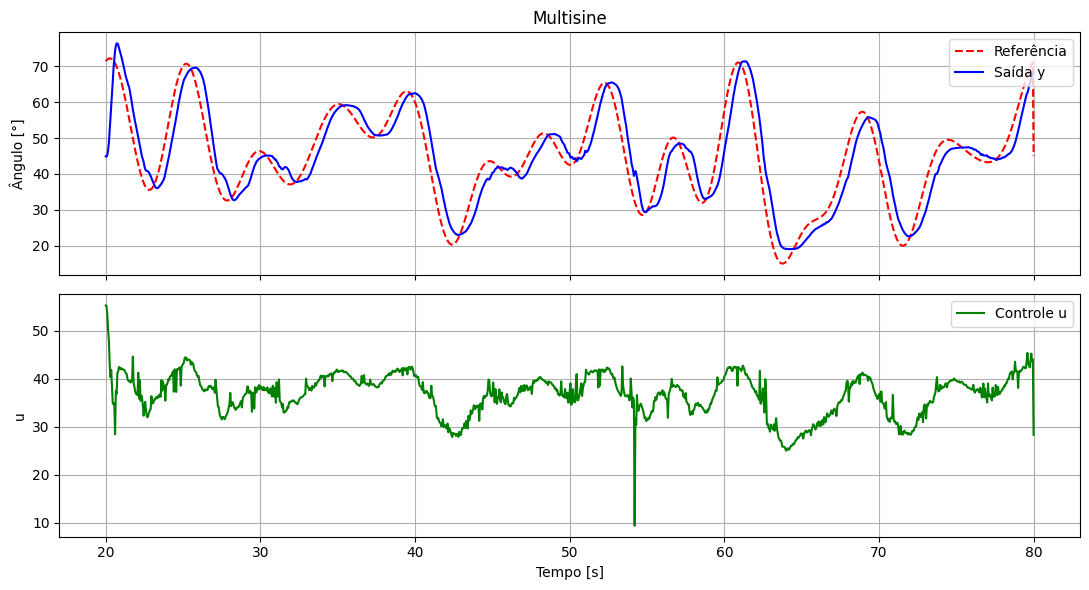

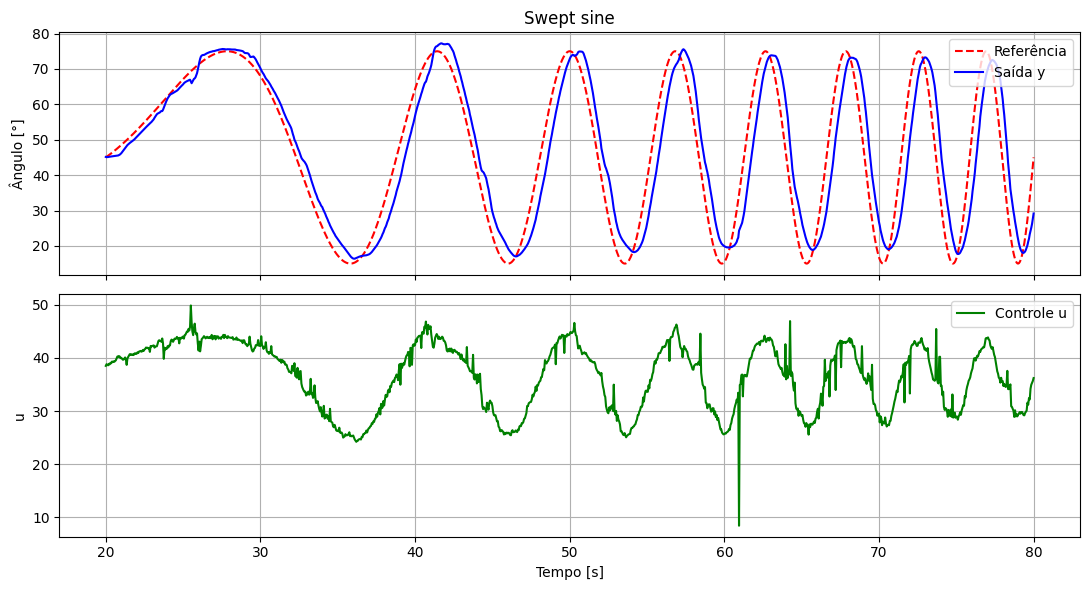

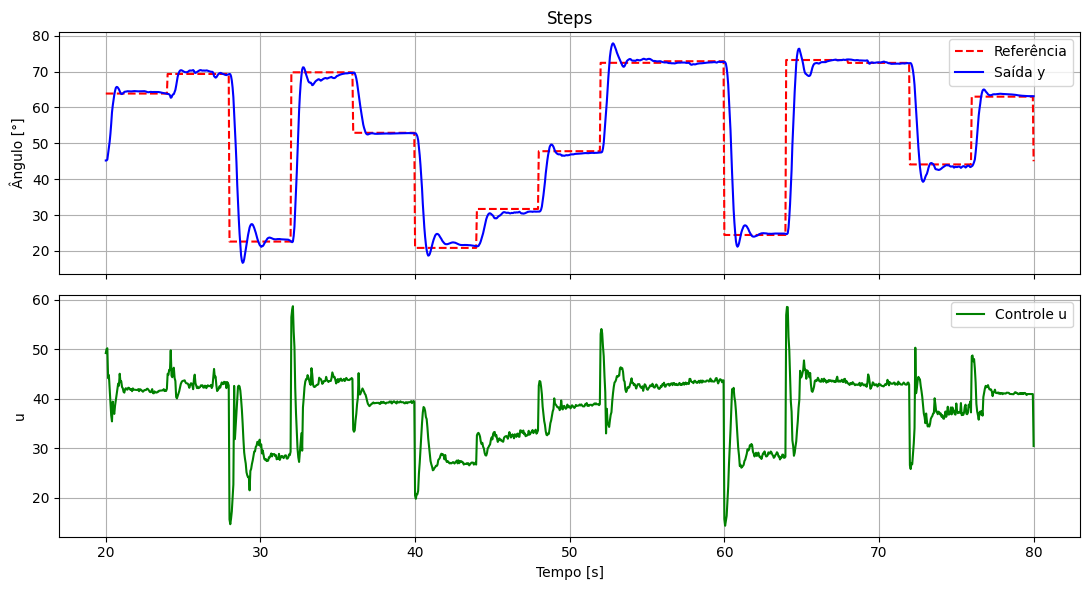

In [3]:
plot_io(*data['multisine'],  'Multisine')
plot_io(*data['swept_sine'], 'Swept sine')
plot_io(*data['steps'],      'Steps')


## Train / test split

**Interleaved 60/40 split**: every dataset is cut into 5 equal blocks (20% each), assigned `train, test, train, test, train` (60% train / 40% test). The NARX model is identified jointly from **all train blocks of all datasets** (`fit` takes a list of `(u, y)` segments).

In [4]:
N_BLOCKS = 5
TRAIN_BLOCKS, TEST_BLOCKS = [0, 2, 4], [1, 3]

def block_bounds(M):
    return [int(round(M * i / N_BLOCKS)) for i in range(N_BLOCKS + 1)]

def dataset_blocks(name):
    u, y, t, ref = data[name]; bnd = block_bounds(len(y))
    train, test = [], []
    for b in range(N_BLOCKS):
        sl = slice(bnd[b], bnd[b+1])
        (train if b in TRAIN_BLOCKS else test).append((u[sl], y[sl]))
    return train

# NARX is fit on a list of (u, y) blocks; build the boolean test mask per dataset
train_data, test_mask = [], {}
for name in data:
    train_data += dataset_blocks(name)
    bnd = block_bounds(len(data[name][1]))
    m = np.zeros(len(data[name][1]), bool)
    for b in TEST_BLOCKS:
        m[bnd[b]:bnd[b+1]] = True
    test_mask[name] = m
print(f'Training blocks: {len(train_data)}  (60% of each of {len(data)} datasets)')


Training blocks: 9  (60% of each of 3 datasets)


## Model identification (multiple datasets)

In [5]:
ny_model = 5
nu_model = 5
poly_order_model = 2
n_components = 10

narx_model = NARX(nu=nu_model, ny=ny_model, poly_order_l=poly_order_model,
                  n_components=n_components)
narx_model.fit(train_data)
narx_model.print()


NARX model — selected terms and parameters
Max lag: 5  (ny=5, nu=5, l=2)
#    Term                                theta     ERR (%)
-------------------------------------------------------
1    y(k-1)                             1.5598   99.973034
2    y(k-2)                            -0.4444    0.025111
3    u(k-2)u(k-5)                       0.0006    0.000471
4    y(k-1)y(k-2)                       0.0002    0.000156
5    y(k-4)                            -0.1577    0.000102
6    u(k-3)u(k-5)                       0.0009    0.000022
7    u(k-4)                             0.0058    0.000007
8    u(k-1)u(k-5)                      -0.0007    0.000003
9    u(k-1)u(k-1)                       0.0003    0.000001
10   u(k-3)u(k-3)                      -0.0003    0.000004
-------------------------------------------------------
Total ERR explained:                 99.998910%


## Final evaluation

Free-run simulation over each **entire** dataset. The shaded region marks the **test** part (last 20% for multisine/steps; the whole signal for swept sine). The reported RMSE is computed on the test region.

Starting Free-Run Simulation for 1196 steps...


FR Simulation:   0%|          | 0/1196 [00:00<?, ?step/s]

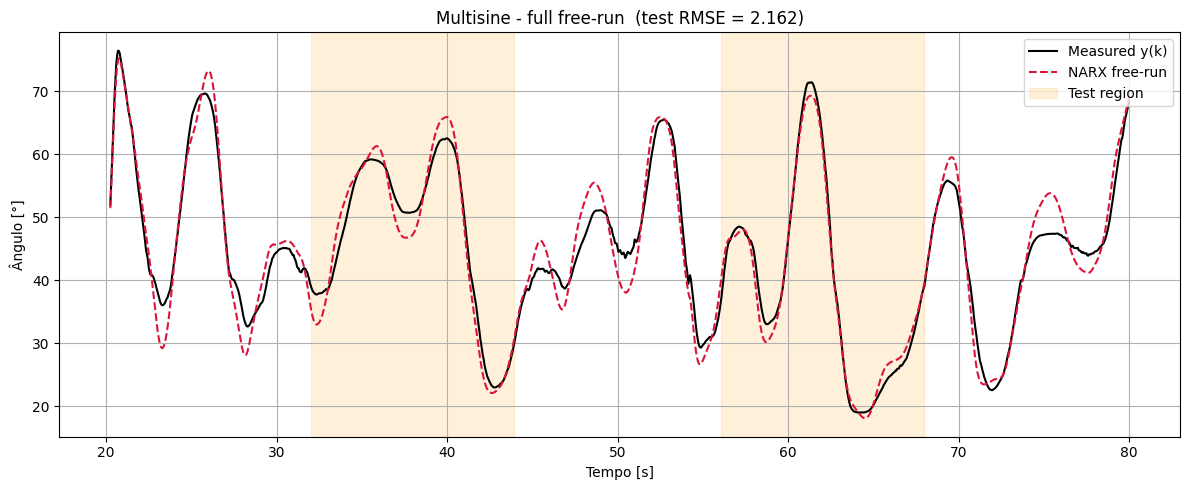

Starting Free-Run Simulation for 1196 steps...


FR Simulation:   0%|          | 0/1196 [00:00<?, ?step/s]

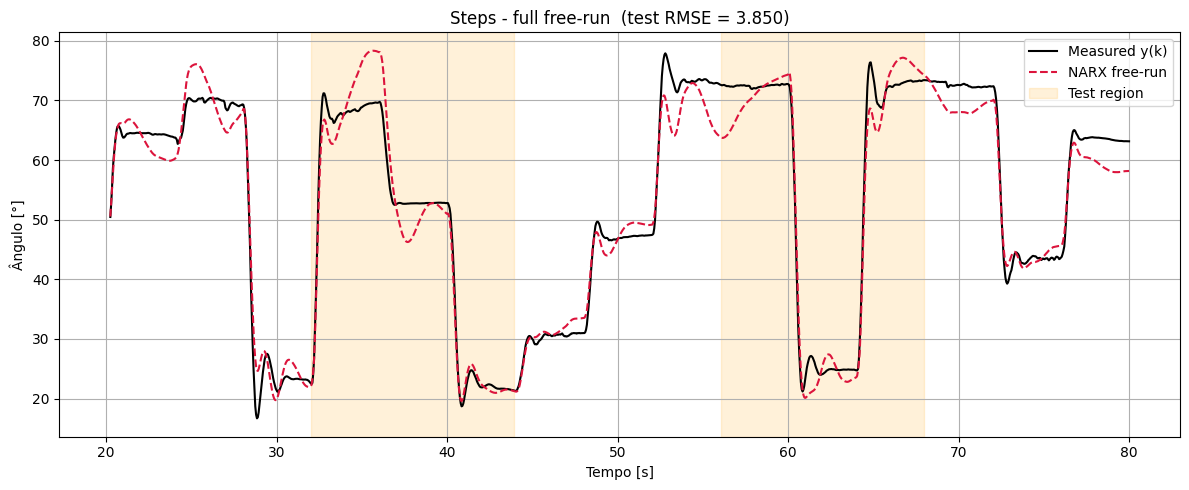

Starting Free-Run Simulation for 1196 steps...


FR Simulation:   0%|          | 0/1196 [00:00<?, ?step/s]

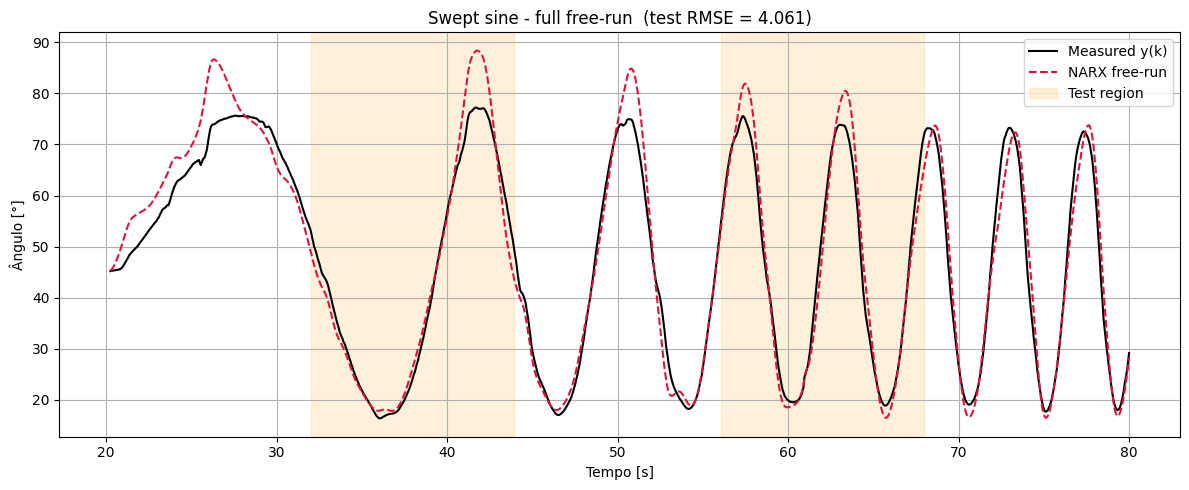


Free-run test RMSE [deg]  |  multisine 2.162   steps 3.850   swept 4.061


In [6]:
def free_run_full(name, title=None):
    u, y, t, ref = data[name]
    ml = narx_model._max_lag_internal_
    y_fr = narx_model.predict(u, y_history_for_lags_or_osa=y[:ml], mode='FR')
    tt, ym = t[ml:], y[ml:]
    m = test_mask[name][ml:]
    rmse_test = np.sqrt(np.mean((ym[m] - y_fr[m]) ** 2))
    plt.figure(figsize=(12, 5))
    plt.plot(tt, ym, color='black', label='Measured y(k)')
    plt.plot(tt, y_fr, '--', color='crimson', label='NARX free-run')
    bnd = block_bounds(len(y)); first = True
    for b in TEST_BLOCKS:
        a0 = max(bnd[b], ml)
        if a0 < bnd[b+1]:
            plt.axvspan(t[a0], t[bnd[b+1]-1], color='orange', alpha=0.15,
                        label='Test region' if first else None); first = False
    plt.xlabel('Tempo [s]'); plt.ylabel('Ângulo [°]')
    plt.title(f'{title or name} - full free-run  (test RMSE = {rmse_test:.3f})')
    plt.legend(loc='upper right'); plt.grid(True); plt.tight_layout(); plt.show()
    return rmse_test

r1 = free_run_full('multisine', 'Multisine')
r2 = free_run_full('steps',     'Steps')
r3 = free_run_full('swept_sine', 'Swept sine')
print(f'\nFree-run test RMSE [deg]  |  multisine {r1:.3f}   steps {r2:.3f}   swept {r3:.3f}')
